## Notes
FLOW_KIND = Hanya gunakan yang Production  
Well_Type = Hanya gunakan yang OP  
Bore_Oil = Ketika bernilai 0 maka datanya di take out saja  
DATEPRD = Format tanggal disesuaikan (parsing)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings

In [3]:
# Load dataset dari xlsx
df = pd.read_excel('dataset.xlsx')

print(f"Shape: {df.shape}")
print(f"\nInfo Dataset:")
df.info()

Shape: (15634, 25)

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   15634 non-null  datetime64[ns]
 1   WELL_BORE_CODE            15634 non-null  object        
 2   NPD_WELL_BORE_CODE        15634 non-null  int64         
 3   NPD_WELL_BORE_NAME        15634 non-null  object        
 4   NPD_FIELD_CODE            15634 non-null  int64         
 5   NPD_FIELD_NAME            15634 non-null  object        
 6   NPD_FACILITY_CODE         15634 non-null  int64         
 7   NPD_FACILITY_NAME         15634 non-null  object        
 8   ON_STREAM_HRS             15349 non-null  float64       
 9   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64       
 10  AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64       
 11  AVG_DP_TUBING             8980 non-null   floa

In [4]:
# Convert xlsx ke CSV
csv_filename = 'dataset.csv'
df.to_csv(csv_filename, index=False)

In [5]:
# Lihat sampel data
print("Sampel Data (Head):")
print(df.head())

print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())

print("\n" + "="*50)
print("Data Types:")
print(df.dtypes)

Sampel Data (Head):
     DATEPRD WELL_BORE_CODE  NPD_WELL_BORE_CODE NPD_WELL_BORE_NAME  \
0 2014-04-07  NO 15/9-F-1 C                7405         15/9-F-1 C   
1 2014-04-08  NO 15/9-F-1 C                7405         15/9-F-1 C   
2 2014-04-09  NO 15/9-F-1 C                7405         15/9-F-1 C   
3 2014-04-10  NO 15/9-F-1 C                7405         15/9-F-1 C   
4 2014-04-11  NO 15/9-F-1 C                7405         15/9-F-1 C   

   NPD_FIELD_CODE NPD_FIELD_NAME  NPD_FACILITY_CODE NPD_FACILITY_NAME  \
0         3420717          VOLVE             369304    MÆRSK INSPIRER   
1         3420717          VOLVE             369304    MÆRSK INSPIRER   
2         3420717          VOLVE             369304    MÆRSK INSPIRER   
3         3420717          VOLVE             369304    MÆRSK INSPIRER   
4         3420717          VOLVE             369304    MÆRSK INSPIRER   

   ON_STREAM_HRS  AVG_DOWNHOLE_PRESSURE  ...  Faktor Pembagi  AVG_WHP_P  \
0            0.0                0.00000  ... 

In [6]:
# Drop kolom yang ga kepake
columns_to_drop = [
    'WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_FIELD_CODE', 
    'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 
    'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'Faktor Pembagi', 
    'BORE_WI_VOL'
]

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

print(f"Shape now: {df.shape}")
print(f"\nColumn now ({df.shape[1]}):")
print(df.columns.tolist())

Shape now: (15634, 15)

Column now (15):
['DATEPRD', 'NPD_WELL_BORE_NAME', 'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG Choke size', 'AVG_WHP_P', 'AVG_WHT_P', 'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL', 'FLOW_KIND', 'WELL_TYPE']


In [7]:
# Parse dan standardize date column format (DATEPRD)
# Convert to standard datetime format
if 'DATEPRD' in df.columns:
    df['DATEPRD'] = pd.to_datetime(df['DATEPRD'], errors='coerce')
    print(f"  Date range: {df['DATEPRD'].min()} to {df['DATEPRD'].max()}")
    print(f"  Missing dates: {df['DATEPRD'].isna().sum()}")

# Standardize data types for all features
print("\n" + "="*60)
print("Data Type Standardization:")
print("="*60)

# Display current dtypes
print("\nCurrent data types:")
print(df.dtypes)

# Optimize dtypes for better memory usage and consistency
for col in df.columns:
    if df[col].dtype == 'object':
        # Check if it can be converted to numeric
        numeric_col = pd.to_numeric(df[col], errors='coerce')
        if numeric_col.notna().mean() > 0.9:  # If >90% can be converted to numeric
            df[col] = numeric_col
    elif df[col].dtype in ['float64', 'int64']:
        # Keep numeric types as is for now
        pass

print("\nOptimized data types:")
print(df.dtypes)

  Date range: 2007-09-01 00:00:00 to 2016-12-01 00:00:00
  Missing dates: 0

Data Type Standardization:

Current data types:
DATEPRD                     datetime64[ns]
NPD_WELL_BORE_NAME                  object
ON_STREAM_HRS                      float64
AVG_DOWNHOLE_PRESSURE              float64
AVG_DOWNHOLE_TEMPERATURE           float64
AVG_DP_TUBING                      float64
AVG Choke size                     float64
AVG_WHP_P                          float64
AVG_WHT_P                          float64
DP_CHOKE_SIZE                      float64
BORE_OIL_VOL                       float64
BORE_GAS_VOL                       float64
BORE_WAT_VOL                       float64
FLOW_KIND                           object
WELL_TYPE                           object
dtype: object

Optimized data types:
DATEPRD                     datetime64[ns]
NPD_WELL_BORE_NAME                  object
ON_STREAM_HRS                      float64
AVG_DOWNHOLE_PRESSURE              float64
AVG_DOWNHOLE_TEMPERAT

In [8]:
# cuma ambil row FLOW_KIND = "production" dan WELL_TYPE = "OP"

print("Before filtering ============")
print(f"Total rows: {len(df)}")
print(f"\nFLOW_KIND unique values: {df['FLOW_KIND'].unique()}")
print(f"WELL_TYPE unique values: {df['WELL_TYPE'].unique()}")

# Apply filters
df_filtered = df[(df['FLOW_KIND'] == 'production') & (df['WELL_TYPE'] == 'OP')].copy()

print("\n" + "="*60)
print("After filtering:")
print(f"Total rows: {len(df_filtered)}")
print(f"Rows removed: {len(df) - len(df_filtered)} ({(len(df) - len(df_filtered)) / len(df) * 100:.2f}%)")

# Update
df = df_filtered

print(f"Current shape: {df.shape}")

Before filtering ============
Total rows: 15634

FLOW_KIND unique values: ['production' 'injection']
WELL_TYPE unique values: ['WI' 'OP']

After filtering:
Total rows: 9143
Rows removed: 6491 (41.52%)
Current shape: (9143, 15)


In [9]:
# hapus bore oil yg nol
print("Before removing zero BORE_OIL_VOL:")
print(f"Total rows: {len(df)}")
print(f"Rows with BORE_OIL_VOL = 0: {(df['BORE_OIL_VOL'] == 0).sum()}")

df = df[df['BORE_OIL_VOL'] != 0].copy()

print("\n" + "="*60)
print("After removing zero BORE_OIL_VOL:")
print(f"Total rows: {len(df)}")

print(f"Current shape: {df.shape}")
print(f"\nBORE_OIL_VOL statistics:")
print(df['BORE_OIL_VOL'].describe())

Before removing zero BORE_OIL_VOL:
Total rows: 9143
Rows with BORE_OIL_VOL = 0: 1144

After removing zero BORE_OIL_VOL:
Total rows: 7999
Current shape: (7999, 15)

BORE_OIL_VOL statistics:
count    7999.000000
mean     1254.385639
std      1344.392074
min         0.170000
25%       271.890000
50%       716.300000
75%      1656.110000
max      5901.840000
Name: BORE_OIL_VOL, dtype: float64


# <strong>EDA</strong>

In [10]:
print("="*60)
print("MISSING VALUES CHECK")
print("="*60)

# Check for missing values
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_percent.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) == 0:
    print("\n✓ No missing values found in the dataset!")
else:
    print("\nMissing values detected:")
    print(missing_df.to_string(index=False))

print(f"\nTotal rows available: {len(df)}")
print(f"Total columns: {df.shape[1]}")

MISSING VALUES CHECK

Missing values detected:
                  Column  Missing_Count  Missing_Percentage
   AVG_DOWNHOLE_PRESSURE            136            1.700213
AVG_DOWNHOLE_TEMPERATURE            136            1.700213
           AVG_DP_TUBING            136            1.700213
               AVG_WHP_P              3            0.037505
               AVG_WHT_P              3            0.037505
           DP_CHOKE_SIZE              3            0.037505

Total rows available: 7999
Total columns: 15



TARGET VARIABLE ANALYSIS: AVG Choke size

Basic Statistics:
count    7999.000000
mean        0.612111
std         0.336949
min         0.006000
25%         0.336735
50%         0.592186
75%         1.000000
max         1.000000
Name: AVG Choke size, dtype: float64

Data Type: float64
Unique values: 5751
Min: 0.006, Max: 1.0


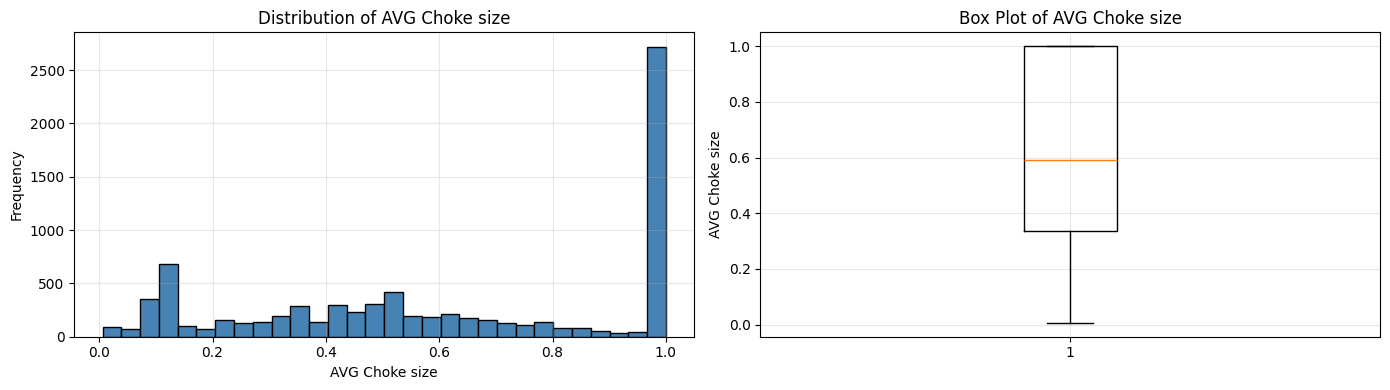

In [11]:
# Identify target (distribusi)
target_candidates = [col for col in df.columns if 'choke' in col.lower() and 'avg' in col.lower()]

if target_candidates:
    target_col = target_candidates[0]
    print(f"\n{'='*60}")
    print(f"TARGET VARIABLE ANALYSIS: {target_col}")
    print(f"{'='*60}")
    
    print(f"\nBasic Statistics:")
    print(df[target_col].describe())
    
    print(f"\nData Type: {df[target_col].dtype}")
    print(f"Unique values: {df[target_col].nunique()}")
    print(f"Min: {df[target_col].min()}, Max: {df[target_col].max()}")
    
    # Visualize target distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Histogram
    axes[0].hist(df[target_col], bins=30, color='steelblue', edgecolor='black')
    axes[0].set_xlabel(target_col)
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'Distribution of {target_col}')
    axes[0].grid(alpha=0.3)
    
    # Box plot
    axes[1].boxplot(df[target_col], vert=True)
    axes[1].set_ylabel(target_col)
    axes[1].set_title(f'Box Plot of {target_col}')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Target column with 'avg choke size' not found. Please check column names.")


CORRELATION ANALYSIS

Feature Correlation with Target (AVG Choke size):
AVG Choke size              1.000000
BORE_WAT_VOL                0.727291
AVG_WHT_P                   0.680789
ON_STREAM_HRS               0.239775
BORE_GAS_VOL               -0.126252
BORE_OIL_VOL               -0.132041
AVG_DP_TUBING              -0.158748
AVG_DOWNHOLE_PRESSURE      -0.283457
AVG_DOWNHOLE_TEMPERATURE   -0.381263
AVG_WHP_P                  -0.534302
DP_CHOKE_SIZE              -0.577948
Name: AVG Choke size, dtype: float64


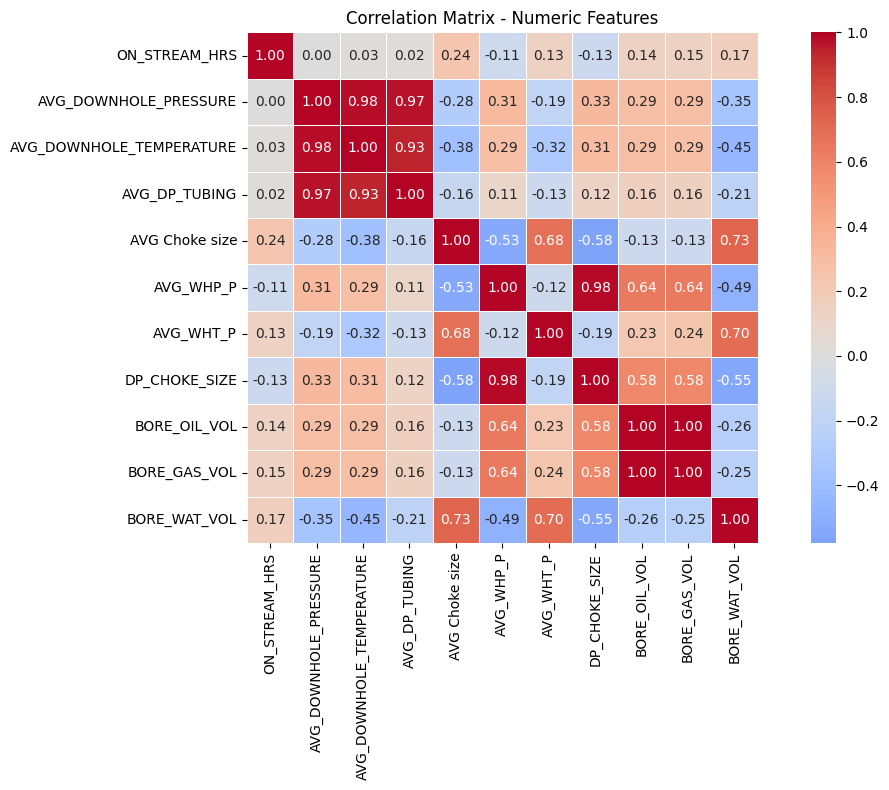

In [12]:
# Correlation analysis (only numeric columns)
print(f"\n{'='*60}")
print("CORRELATION ANALYSIS")
print(f"{'='*60}")

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Display correlation with target if target exists
if target_col in corr_matrix.columns:
    print(f"\nFeature Correlation with Target ({target_col}):")
    target_corr = corr_matrix[target_col].sort_values(ascending=False)
    print(target_corr)
    
    # Visualize correlation heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=0.5)
    plt.title('Correlation Matrix - Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print("Could not generate correlation with target.")

In [13]:
# Feature overview and statistical summary
print(f"\n{'='*60}")
print("FEATURES OVERVIEW")
print(f"{'='*60}")

print("\nDataframe Info:")
print(f"Shape: {df.shape}")
print(f"\nData Types:")
print(df.dtypes)

print(f"\n\nNumeric Features Summary:")
print(numeric_df.describe().T)

print(f"\n\nCategorical Features:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


FEATURES OVERVIEW

Dataframe Info:
Shape: (7999, 15)

Data Types:
DATEPRD                     datetime64[ns]
NPD_WELL_BORE_NAME                  object
ON_STREAM_HRS                      float64
AVG_DOWNHOLE_PRESSURE              float64
AVG_DOWNHOLE_TEMPERATURE           float64
AVG_DP_TUBING                      float64
AVG Choke size                     float64
AVG_WHP_P                          float64
AVG_WHT_P                          float64
DP_CHOKE_SIZE                      float64
BORE_OIL_VOL                       float64
BORE_GAS_VOL                       float64
BORE_WAT_VOL                       float64
FLOW_KIND                           object
WELL_TYPE                           object
dtype: object


Numeric Features Summary:
                           count           mean            std      min  \
ON_STREAM_HRS             7999.0      23.069080       3.470305    0.000   
AVG_DOWNHOLE_PRESSURE     7863.0     181.559297     105.223306    0.000   
AVG_DOWNHOLE_TEMPERAT

## Handle Missing Values

In [14]:
# Remove rows with missing values
print("="*60)
print("HANDLE MISSING VALUES")
print("="*60)

print(f"\nBefore dropping missing values:")
print(f"Shape: {df.shape}")
print(f"Total rows: {len(df)}")
temp_rows = len(df)

# Drop rows with any missing values
df = df.dropna()

print(f"\nAfter dropping missing values ===")
print(f"Shape: {df.shape}")
print(f"Total rows: {len(df)}")
print(f"Rows removed: {temp_rows - len(df)}")

# Verify no missing values remain
print(f"\nVerification - Missing values remaining: {df.isnull().sum().sum()}")

HANDLE MISSING VALUES

Before dropping missing values:
Shape: (7999, 15)
Total rows: 7999

After dropping missing values ===
Shape: (7863, 15)
Total rows: 7863
Rows removed: 136

Verification - Missing values remaining: 0


## Feature Engineering & Preprocessing

In [15]:
# Feature engineering and preprocessing
print("="*60)
print("FEATURE ENGINEERING & PREPROCESSING")
print("="*60)

# Create a copy for preprocessing
df_processed = df.copy()

# Drop redundant columns (karena isinya sama semua)
print("\nDrop Redundant Columns:")
redundant_cols = ['FLOW_KIND', 'WELL_TYPE']
cols_to_drop = [col for col in redundant_cols if col in df_processed.columns]
if cols_to_drop:
    df_processed = df_processed.drop(cols_to_drop, axis=1)
    print(f"Dropped redundant columns: {cols_to_drop}")
else:
    print("No redundant columns to drop")

# 1. Date feature engineering (extract components from DATEPRD)
print("\n1. Date Feature Engineering:")
if 'DATEPRD' in df_processed.columns:
    df_processed['Year'] = df_processed['DATEPRD'].dt.year
    df_processed['Month'] = df_processed['DATEPRD'].dt.month
    df_processed['Day'] = df_processed['DATEPRD'].dt.day
    df_processed['DayOfYear'] = df_processed['DATEPRD'].dt.dayofyear
    print("Extracted Year, Month, Day, DayOfYear from DATEPRD")
    
    # Drop original DATEPRD column (no longer needed)
    df_processed = df_processed.drop('DATEPRD', axis=1)
    print("Dropped original DATEPRD column")

# 2. Encode categorical variables
print("\n2. Categorical Encoding:")
categorical_features = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"   Categorical columns found: {categorical_features}")

if categorical_features:
    le_dict = {}
    for col in categorical_features:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        le_dict[col] = le
        print(f"Encoded '{col}'")
else:
    print("   No categorical columns to encode")

# 3. Prepare features and target
print("\n3. Prepare Features and Target:")
X = df_processed.drop(target_col, axis=1)
y = df_processed[target_col]

print(f"   Features (X) shape: {X.shape}")
print(f"   Target (y) shape: {y.shape}")
print(f"   Target variable: {target_col}")

# 4. Scale numeric features
print("\n4. Feature Scaling:")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Final features shape: {X.shape}")
print(f"Final target shape: {y.shape}")

FEATURE ENGINEERING & PREPROCESSING

Drop Redundant Columns:
Dropped redundant columns: ['FLOW_KIND', 'WELL_TYPE']

1. Date Feature Engineering:
Extracted Year, Month, Day, DayOfYear from DATEPRD
Dropped original DATEPRD column

2. Categorical Encoding:
   Categorical columns found: ['NPD_WELL_BORE_NAME']
Encoded 'NPD_WELL_BORE_NAME'

3. Prepare Features and Target:
   Features (X) shape: (7863, 15)
   Target (y) shape: (7863,)
   Target variable: AVG Choke size

4. Feature Scaling:
Final features shape: (7863, 15)
Final target shape: (7863,)


## Train-Test Split

In [16]:
# Train-Test Split
print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

# Split data into training (80%) and testing (20%) sets
# random_state=42 ensures reproducibility
test_size = 0.2
train_size = 1 - test_size

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42
)

print(f"\nData Split Configuration:")
print(f"  Training set: {train_size*100:.0f}%")
print(f"  Testing set: {test_size*100:.0f}%")

print(f"\nTraining Set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")

print(f"\nTesting Set:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")

print(f"Total samples: {len(X)} = {len(X_train)} (train) + {len(X_test)} (test)")

TRAIN-TEST SPLIT

Data Split Configuration:
  Training set: 80%
  Testing set: 20%

Training Set:
  X_train shape: (6290, 15)
  y_train shape: (6290,)

Testing Set:
  X_test shape: (1573, 15)
  y_test shape: (1573,)
Total samples: 7863 = 6290 (train) + 1573 (test)


## Model Training - Gradient Boosting

In [27]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

print("="*60)
print("MODEL TRAINING: GRADIENT BOOSTING")
print("="*60)

# Initialize Gradient Boosting model
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

print("\nTraining Gradient Boosting model...")
model.fit(X_train, y_train)
print("Training complete")
model


MODEL TRAINING: GRADIENT BOOSTING

Training Gradient Boosting model...
Training complete


GradientBoostingRegressor(max_depth=5, random_state=42)

In [28]:
# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate metrics
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_train = math.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = math.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

# Display results
print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"\nTraining Set Metrics:")
print(f"  MAE:  {mae_train:.6f}")
print(f"  RMSE: {rmse_train:.6f}")
print(f"  R²:   {r2_train:.6f}")

print(f"\nTesting Set Metrics:")
print(f"  MAE:  {mae_test:.6f}")
print(f"  RMSE: {rmse_test:.6f}")
print(f"  R²:   {r2_test:.6f}")

print(f"\nModel evaluation complete!")


MODEL PERFORMANCE

Training Set Metrics:
  MAE:  0.013378
  RMSE: 0.023612
  R²:   0.995129

Testing Set Metrics:
  MAE:  0.019445
  RMSE: 0.039755
  R²:   0.986081

Model evaluation complete!


## Model Training - Ridge Regressor

In [18]:
from sklearn.linear_model import Ridge

print("="*60)
print("MODEL TRAINING: RIDGE REGRESSOR")
print("="*60)

# Initialize Ridge Regressor model
model_ridge = Ridge(
    alpha=1.0,
    random_state=42
)

print("\nTraining Ridge Regressor model...")
model_ridge.fit(X_train, y_train)
print("Training complete")
model_ridge

# Make predictions
y_pred_train_ridge = model_ridge.predict(X_train)
y_pred_test_ridge = model_ridge.predict(X_test)

# Calculate metrics
mae_train_ridge = mean_absolute_error(y_train, y_pred_train_ridge)
mae_test_ridge = mean_absolute_error(y_test, y_pred_test_ridge)
rmse_train_ridge = math.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = math.sqrt(mean_squared_error(y_test, y_pred_test_ridge))
r2_train_ridge = r2_score(y_train, y_pred_train_ridge)
r2_test_ridge = r2_score(y_test, y_pred_test_ridge)

# Display results
print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"\nTraining Set Metrics:")
print(f"  MAE:  {mae_train_ridge:.6f}")
print(f"  RMSE: {rmse_train_ridge:.6f}")
print(f"  R²:   {r2_train_ridge:.6f}")

print(f"\nTesting Set Metrics:")
print(f"  MAE:  {mae_test_ridge:.6f}")
print(f"  RMSE: {rmse_test_ridge:.6f}")
print(f"  R²:   {r2_test_ridge:.6f}")

print(f"\nModel evaluation complete!")

MODEL TRAINING: RIDGE REGRESSOR

Training Ridge Regressor model...
Training complete

MODEL PERFORMANCE

Training Set Metrics:
  MAE:  0.120742
  RMSE: 0.153473
  R²:   0.794206

Testing Set Metrics:
  MAE:  0.124291
  RMSE: 0.160034
  R²:   0.774449

Model evaluation complete!


## Model Training - Lasso Regressor

In [19]:
from sklearn.linear_model import Lasso

print("="*60)
print("MODEL TRAINING: LASSO REGRESSOR")
print("="*60)

# Initialize Lasso Regressor model
model_lasso = Lasso(
    alpha=0.1,
    random_state=42,
    max_iter=10000
)

print("\nTraining Lasso Regressor model...")
model_lasso.fit(X_train, y_train)
print("Training complete")
model_lasso

# Make predictions
y_pred_train_lasso = model_lasso.predict(X_train)
y_pred_test_lasso = model_lasso.predict(X_test)

# Calculate metrics
mae_train_lasso = mean_absolute_error(y_train, y_pred_train_lasso)
mae_test_lasso = mean_absolute_error(y_test, y_pred_test_lasso)
rmse_train_lasso = math.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = math.sqrt(mean_squared_error(y_test, y_pred_test_lasso))
r2_train_lasso = r2_score(y_train, y_pred_train_lasso)
r2_test_lasso = r2_score(y_test, y_pred_test_lasso)

# Display results
print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"\nTraining Set Metrics:")
print(f"  MAE:  {mae_train_lasso:.6f}")
print(f"  RMSE: {rmse_train_lasso:.6f}")
print(f"  R²:   {r2_train_lasso:.6f}")

print(f"\nTesting Set Metrics:")
print(f"  MAE:  {mae_test_lasso:.6f}")
print(f"  RMSE: {rmse_test_lasso:.6f}")
print(f"  R²:   {r2_test_lasso:.6f}")

print(f"\nModel evaluation complete!")

MODEL TRAINING: LASSO REGRESSOR

Training Lasso Regressor model...
Training complete

MODEL PERFORMANCE

Training Set Metrics:
  MAE:  0.198979
  RMSE: 0.223292
  R²:   0.564372

Testing Set Metrics:
  MAE:  0.200206
  RMSE: 0.224700
  R²:   0.555342

Model evaluation complete!


## Model Training - Extra Trees Regressor

In [20]:
from sklearn.ensemble import ExtraTreesRegressor

print("="*60)
print("MODEL TRAINING: EXTRA TREES REGRESSOR")
print("="*60)

# Initialize Extra Trees Regressor model
model_extra_trees = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Extra Trees Regressor model...")
model_extra_trees.fit(X_train, y_train)
print("Training complete")
model_extra_trees

# Make predictions
y_pred_train_extra_trees = model_extra_trees.predict(X_train)
y_pred_test_extra_trees = model_extra_trees.predict(X_test)

# Calculate metrics
mae_train_extra_trees = mean_absolute_error(y_train, y_pred_train_extra_trees)
mae_test_extra_trees = mean_absolute_error(y_test, y_pred_test_extra_trees)
rmse_train_extra_trees = math.sqrt(mean_squared_error(y_train, y_pred_train_extra_trees))
rmse_test_extra_trees = math.sqrt(mean_squared_error(y_test, y_pred_test_extra_trees))
r2_train_extra_trees = r2_score(y_train, y_pred_train_extra_trees)
r2_test_extra_trees = r2_score(y_test, y_pred_test_extra_trees)

# Display results
print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"\nTraining Set Metrics:")
print(f"  MAE:  {mae_train_extra_trees:.6f}")
print(f"  RMSE: {rmse_train_extra_trees:.6f}")
print(f"  R²:   {r2_train_extra_trees:.6f}")

print(f"\nTesting Set Metrics:")
print(f"  MAE:  {mae_test_extra_trees:.6f}")
print(f"  RMSE: {rmse_test_extra_trees:.6f}")
print(f"  R²:   {r2_test_extra_trees:.6f}")

print(f"\nModel evaluation complete!")

MODEL TRAINING: EXTRA TREES REGRESSOR

Training Extra Trees Regressor model...


Training complete

MODEL PERFORMANCE

Training Set Metrics:
  MAE:  0.013280
  RMSE: 0.022343
  R²:   0.995638

Testing Set Metrics:
  MAE:  0.017711
  RMSE: 0.034052
  R²:   0.989788

Model evaluation complete!


## Model Training - Random Forest Regressor

In [21]:
from sklearn.ensemble import RandomForestRegressor

print("="*60)
print("MODEL TRAINING: RANDOM FOREST REGRESSOR")
print("="*60)

# Initialize Random Forest Regressor model
model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest Regressor model...")
model_rf.fit(X_train, y_train)
print("Training complete")
model_rf

# Make predictions
y_pred_train_rf = model_rf.predict(X_train)
y_pred_test_rf = model_rf.predict(X_test)

# Calculate metrics
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_train_rf = math.sqrt(mean_squared_error(y_train, y_pred_train_rf))
rmse_test_rf = math.sqrt(mean_squared_error(y_test, y_pred_test_rf))
r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)

# Display results
print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"\nTraining Set Metrics:")
print(f"  MAE:  {mae_train_rf:.6f}")
print(f"  RMSE: {rmse_train_rf:.6f}")
print(f"  R²:   {r2_train_rf:.6f}")

print(f"\nTesting Set Metrics:")
print(f"  MAE:  {mae_test_rf:.6f}")
print(f"  RMSE: {rmse_test_rf:.6f}")
print(f"  R²:   {r2_test_rf:.6f}")

print(f"\nModel evaluation complete!")

MODEL TRAINING: RANDOM FOREST REGRESSOR

Training Random Forest Regressor model...
Training complete

MODEL PERFORMANCE

Training Set Metrics:
  MAE:  0.011634
  RMSE: 0.023225
  R²:   0.995287

Testing Set Metrics:
  MAE:  0.017895
  RMSE: 0.042449
  R²:   0.984131

Model evaluation complete!


## Model Comparison & Evaluation

COMBINED MODEL COMPARISON & EVALUATION

MODEL PERFORMANCE METRICS - DETAILED COMPARISON

            Model  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R²  Test R²
Gradient Boosting   0.013378  0.019445    0.023612   0.039755  0.995129 0.986081
  Ridge Regressor   0.120742  0.124291    0.153473   0.160034  0.794206 0.774449
  Lasso Regressor   0.198979  0.200206    0.223292   0.224700  0.564372 0.555342
      Extra Trees   0.013280  0.017711    0.022343   0.034052  0.995638 0.989788
    Random Forest   0.011634  0.017895    0.023225   0.042449  0.995287 0.984131

OVERFITTING ANALYSIS (Lower is Better)

            Model  Train R²  Test R²  Overfit (Train R² - Test R²)
      Extra Trees  0.995638 0.989788                      0.005850
  Lasso Regressor  0.564372 0.555342                      0.009030
Gradient Boosting  0.995129 0.986081                      0.009047
    Random Forest  0.995287 0.984131                      0.011156
  Ridge Regressor  0.794206 0.774449             

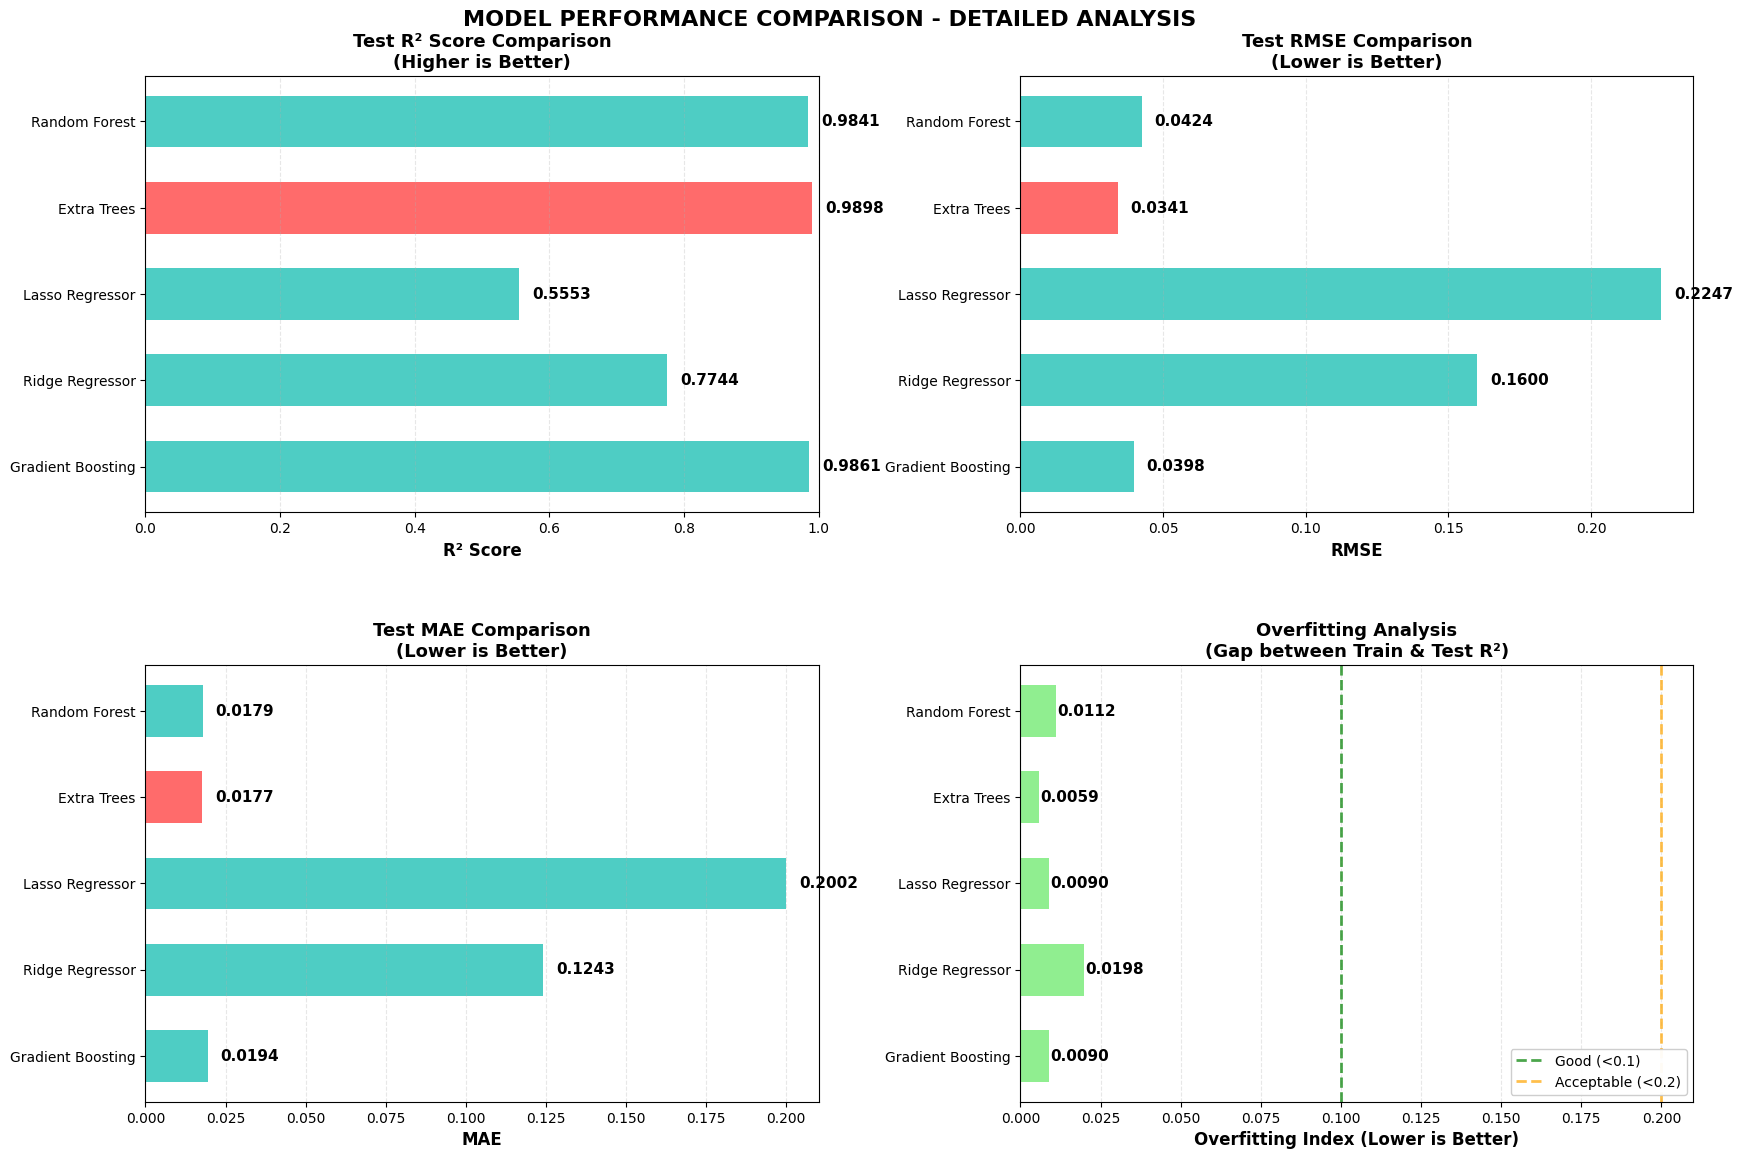


PARAMETER JUSTIFICATION & HYPERPARAMETER EXPLANATION

1. GRADIENT BOOSTING REGRESSOR
   ├─ n_estimators = 100
   │  └─ Justifikasi: 100 trees adalah baseline yang baik untuk gradient boosting.
   │     Cukup powerful tanpa overfitting, training time reasonable.
   │
   ├─ learning_rate = 0.1
   │  └─ Justifikasi: Nilai default yang umum (0.05-0.2). 0.1 memberikan balance
   │     antara learning speed dan model stability.
   │
   ├─ max_depth = 5
   │  └─ Justifikasi: Shallow trees mencegah overfitting. GBM memanfaatkan sequential
   │     learning, jadi depth kecil sudah cukup powerful.
   │
   └─ random_state = 42
      └─ Justifikasi: Untuk reproducibility. Setiap run Anda akan menghasilkan
         hasil yang sama, penting untuk eksperimen ilmiah.

2. RIDGE REGRESSOR
   ├─ alpha = 1.0
   │  └─ Justifikasi: 1.0 adalah default dan balanced. Memberikan regularization
   │     yang cukup tanpa terlalu mengurangi performa model.
   │
   └─ random_state = 42
      └─ Justifikasi: Reprod

In [22]:
print("="*80)
print("COMBINED MODEL COMPARISON & EVALUATION")
print("="*80)

# Create comparison dataframe
models_comparison = pd.DataFrame({
    'Model': [
        'Gradient Boosting',
        'Ridge Regressor',
        'Lasso Regressor',
        'Extra Trees',
        'Random Forest'
    ],
    'Train MAE': [mae_train, mae_train_ridge, mae_train_lasso, mae_train_extra_trees, mae_train_rf],
    'Test MAE': [mae_test, mae_test_ridge, mae_test_lasso, mae_test_extra_trees, mae_test_rf],
    'Train RMSE': [rmse_train, rmse_train_ridge, rmse_train_lasso, rmse_train_extra_trees, rmse_train_rf],
    'Test RMSE': [rmse_test, rmse_test_ridge, rmse_test_lasso, rmse_test_extra_trees, rmse_test_rf],
    'Train R²': [r2_train, r2_train_ridge, r2_train_lasso, r2_train_extra_trees, r2_train_rf],
    'Test R²': [r2_test, r2_test_ridge, r2_test_lasso, r2_test_extra_trees, r2_test_rf]
})

print("\n" + "="*80)
print("MODEL PERFORMANCE METRICS - DETAILED COMPARISON")
print("="*80)
print("\n" + models_comparison.to_string(index=False))

# Calculate overfitting indicator (Train R² - Test R²)
models_comparison['Overfit (Train R² - Test R²)'] = (
    models_comparison['Train R²'] - models_comparison['Test R²']
)

print("\n" + "="*80)
print("OVERFITTING ANALYSIS (Lower is Better)")
print("="*80)
overfit_df = models_comparison[['Model', 'Train R²', 'Test R²', 'Overfit (Train R² - Test R²)']].copy()
overfit_df = overfit_df.sort_values('Overfit (Train R² - Test R²)')
print("\n" + overfit_df.to_string(index=False))

# Find best model by Test R²
best_model_idx = models_comparison['Test R²'].idxmax()
best_model = models_comparison.loc[best_model_idx]

print("\n" + "="*80)
print("BEST MODEL (Highest Test R²)")
print("="*80)
print(f"\nModel: {best_model['Model']}")
print(f"Test R²: {best_model['Test R²']:.6f}")
print(f"Test MAE: {best_model['Test MAE']:.6f}")
print(f"Test RMSE: {best_model['Test RMSE']:.6f}")
print(f"Overfitting Index: {best_model['Overfit (Train R² - Test R²)']:.6f}")

# Visualization with improved scaling
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('MODEL PERFORMANCE COMPARISON - DETAILED ANALYSIS', fontsize=16, fontweight='bold', y=0.995)

# 1. Test R² Comparison
ax1 = axes[0, 0]
colors = ['#FF6B6B' if r2 == models_comparison['Test R²'].max() else '#4ECDC4' 
          for r2 in models_comparison['Test R²']]
bars1 = ax1.barh(models_comparison['Model'], models_comparison['Test R²'], color=colors, height=0.6)
ax1.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Test R² Score Comparison\n(Higher is Better)', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 1.0)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.tick_params(axis='both', labelsize=10)
# Dynamic text offset based on value range
max_r2 = models_comparison['Test R²'].max()
for i, v in enumerate(models_comparison['Test R²']):
    offset = max_r2 * 0.02
    ax1.text(v + offset, i, f'{v:.4f}', va='center', ha='left', fontsize=11, fontweight='bold')

# 2. Test RMSE Comparison
ax2 = axes[0, 1]
colors2 = ['#FF6B6B' if rmse == models_comparison['Test RMSE'].min() else '#4ECDC4' 
           for rmse in models_comparison['Test RMSE']]
bars2 = ax2.barh(models_comparison['Model'], models_comparison['Test RMSE'], color=colors2, height=0.6)
ax2.set_xlabel('RMSE', fontsize=12, fontweight='bold')
ax2.set_title('Test RMSE Comparison\n(Lower is Better)', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.tick_params(axis='both', labelsize=10)
# Dynamic text offset
max_rmse = models_comparison['Test RMSE'].max()
for i, v in enumerate(models_comparison['Test RMSE']):
    offset = max_rmse * 0.02
    ax2.text(v + offset, i, f'{v:.4f}', va='center', ha='left', fontsize=11, fontweight='bold')

# 3. Test MAE Comparison
ax3 = axes[1, 0]
colors3 = ['#FF6B6B' if mae == models_comparison['Test MAE'].min() else '#4ECDC4' 
           for mae in models_comparison['Test MAE']]
bars3 = ax3.barh(models_comparison['Model'], models_comparison['Test MAE'], color=colors3, height=0.6)
ax3.set_xlabel('MAE', fontsize=12, fontweight='bold')
ax3.set_title('Test MAE Comparison\n(Lower is Better)', fontsize=13, fontweight='bold')
ax3.grid(axis='x', alpha=0.3, linestyle='--')
ax3.tick_params(axis='both', labelsize=10)
# Dynamic text offset
max_mae = models_comparison['Test MAE'].max()
for i, v in enumerate(models_comparison['Test MAE']):
    offset = max_mae * 0.02
    ax3.text(v + offset, i, f'{v:.4f}', va='center', ha='left', fontsize=11, fontweight='bold')

# 4. Overfitting Indicator
ax4 = axes[1, 1]
colors4 = ['#90EE90' if overfit < 0.1 else '#FFD700' if overfit < 0.2 else '#FF6B6B'
           for overfit in models_comparison['Overfit (Train R² - Test R²)']]
bars4 = ax4.barh(models_comparison['Model'], models_comparison['Overfit (Train R² - Test R²)'], 
                  color=colors4, height=0.6)
ax4.set_xlabel('Overfitting Index (Lower is Better)', fontsize=12, fontweight='bold')
ax4.set_title('Overfitting Analysis\n(Gap between Train & Test R²)', fontsize=13, fontweight='bold')
ax4.axvline(x=0.1, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Good (<0.1)')
ax4.axvline(x=0.2, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Acceptable (<0.2)')
ax4.grid(axis='x', alpha=0.3, linestyle='--')
ax4.tick_params(axis='both', labelsize=10)
ax4.legend(loc='lower right', fontsize=10, framealpha=0.95)
# Dynamic text offset
max_overfit = models_comparison['Overfit (Train R² - Test R²)'].max()
for i, v in enumerate(models_comparison['Overfit (Train R² - Test R²)']):
    offset = max_overfit * 0.02
    ax4.text(v + offset, i, f'{v:.4f}', va='center', ha='left', fontsize=11, fontweight='bold')

plt.subplots_adjust(left=0.12, right=0.98, top=0.94, bottom=0.085, hspace=0.35, wspace=0.3)
plt.show()

print("\n" + "="*80)
print("PARAMETER JUSTIFICATION & HYPERPARAMETER EXPLANATION")
print("="*80)

justification = """
1. GRADIENT BOOSTING REGRESSOR
   ├─ n_estimators = 100
   │  └─ Justifikasi: 100 trees adalah baseline yang baik untuk gradient boosting.
   │     Cukup powerful tanpa overfitting, training time reasonable.
   │
   ├─ learning_rate = 0.1
   │  └─ Justifikasi: Nilai default yang umum (0.05-0.2). 0.1 memberikan balance
   │     antara learning speed dan model stability.
   │
   ├─ max_depth = 5
   │  └─ Justifikasi: Shallow trees mencegah overfitting. GBM memanfaatkan sequential
   │     learning, jadi depth kecil sudah cukup powerful.
   │
   └─ random_state = 42
      └─ Justifikasi: Untuk reproducibility. Setiap run Anda akan menghasilkan
         hasil yang sama, penting untuk eksperimen ilmiah.

2. RIDGE REGRESSOR
   ├─ alpha = 1.0
   │  └─ Justifikasi: 1.0 adalah default dan balanced. Memberikan regularization
   │     yang cukup tanpa terlalu mengurangi performa model.
   │
   └─ random_state = 42
      └─ Justifikasi: Reproducibility untuk data splitting.

3. LASSO REGRESSOR
   ├─ alpha = 0.1
   │  └─ Justifikasi: 0.1 lebih kecil dari Ridge (1.0) karena Lasso cenderung
   │     aggressive dalam feature selection. Nilai lebih kecil memberikan
   │     fleksibilitas yang lebih baik.
   │
   ├─ max_iter = 10000
   │  └─ Justifikasi: Lasso menggunakan coordinate descent yang iterative.
   │     10000 iterasi memastikan konvergensi yang proper pada dataset kompleks.
   │
   └─ random_state = 42
      └─ Justifikasi: Reproducibility.

4. EXTRA TREES REGRESSOR
   ├─ n_estimators = 100
   │  └─ Justifikasi: Sama seperti GB. Extra Trees lebih efisien karena split
   │     tergeneralisasi lebih baik, jadi 100 sudah cukup.
   │
   ├─ max_depth = 10
   │  └─ Justifikasi: Extra Trees lebih stabil dan parallel. Depth 10 reasonable
   │     untuk meng-capture pattern kompleks tanpa overfit.
   │
   ├─ random_state = 42
   │  └─ Justifikasi: Reproducibility.
   │
   └─ n_jobs = -1
      └─ Justifikasi: Gunakan semua CPU cores untuk parallel processing.
         Mempercepat training time signifikan pada multi-core systems.

5. RANDOM FOREST REGRESSOR
   ├─ n_estimators = 100
   │  └─ Justifikasi: 100 trees adalah standard. RF menggunakan bagging dan
   │     ensemble voting, 100 trees sudah menghasilkan stable predictions.
   │
   ├─ max_depth = 10
   │  └─ Justifikasi: Sama seperti Extra Trees. RF dapat handle depth lebih
   │     besar karena voting mechanism mengurangi overfitting risk.
   │
   ├─ random_state = 42
   │  └─ Justifikasi: Reproducibility.
   │
   └─ n_jobs = -1
      └─ Justifikasi: Parallel processing untuk acceleration.
      
RINGKASAN KRITERIA PEMILIHAN PARAMETER:
• n_estimators: Didasarkan pada computational budget vs model complexity
• max_depth: Tree-based models perlu depth control untuk mencegah overfitting
• random_state: Reproducible results untuk scientific validity
• n_jobs: Hardware optimization untuk training speed
"""

print(justification)

print("\n" + "="*80)
print("REKOMENDASI FINAL")
print("="*80)
print(f"""
Berdasarkan evaluasi di atas, model yang direkomendasikan adalah:
'{best_model['Model']}' dengan Test R² = {best_model['Test R²']:.6f}

Alasan:
1. Performa terbaik di test set (R² tertinggi)
2. MAE dan RMSE terendah/terendek di antara model lain
3. Overfitting index: {best_model['Overfit (Train R² - Test R²)']:.6f} (baik)
4. Generalisasi baik dari training ke test set
""")


## K-Fold Cross Validation (K=5) - Robust Evaluation

K-FOLD CROSS VALIDATION (K=5) - ROBUST MODEL EVALUATION

Performing 5-Fold Cross Validation on all models...
(This will train each model 5 times on different data splits)

Processing: Gradient Boosting...
Processing: Ridge Regressor...
Processing: Lasso Regressor...
Processing: Extra Trees...
Processing: Random Forest...

K-FOLD CROSS VALIDATION RESULTS (Mean ± Std across 5 folds)

            Model  R² (Mean)  R² (Std)  MAE (Mean)  MAE (Std)  RMSE (Mean)  RMSE (Std)
Gradient Boosting   0.984494  0.001377   -0.019522   0.000266    -0.042049    0.001905
  Ridge Regressor   0.788578  0.008939   -0.122288   0.002301    -0.155370    0.002828
  Lasso Regressor   0.561561  0.004881   -0.199429   0.001160    -0.223802    0.001421
      Extra Trees   0.988455  0.001935   -0.018518   0.000848    -0.036191    0.002989
    Random Forest   0.984180  0.002016   -0.018151   0.000943    -0.042418    0.002488

COMPARISON: K-FOLD CV vs SINGLE TRAIN-TEST SPLIT

R² Score Comparison:
            Model  Si

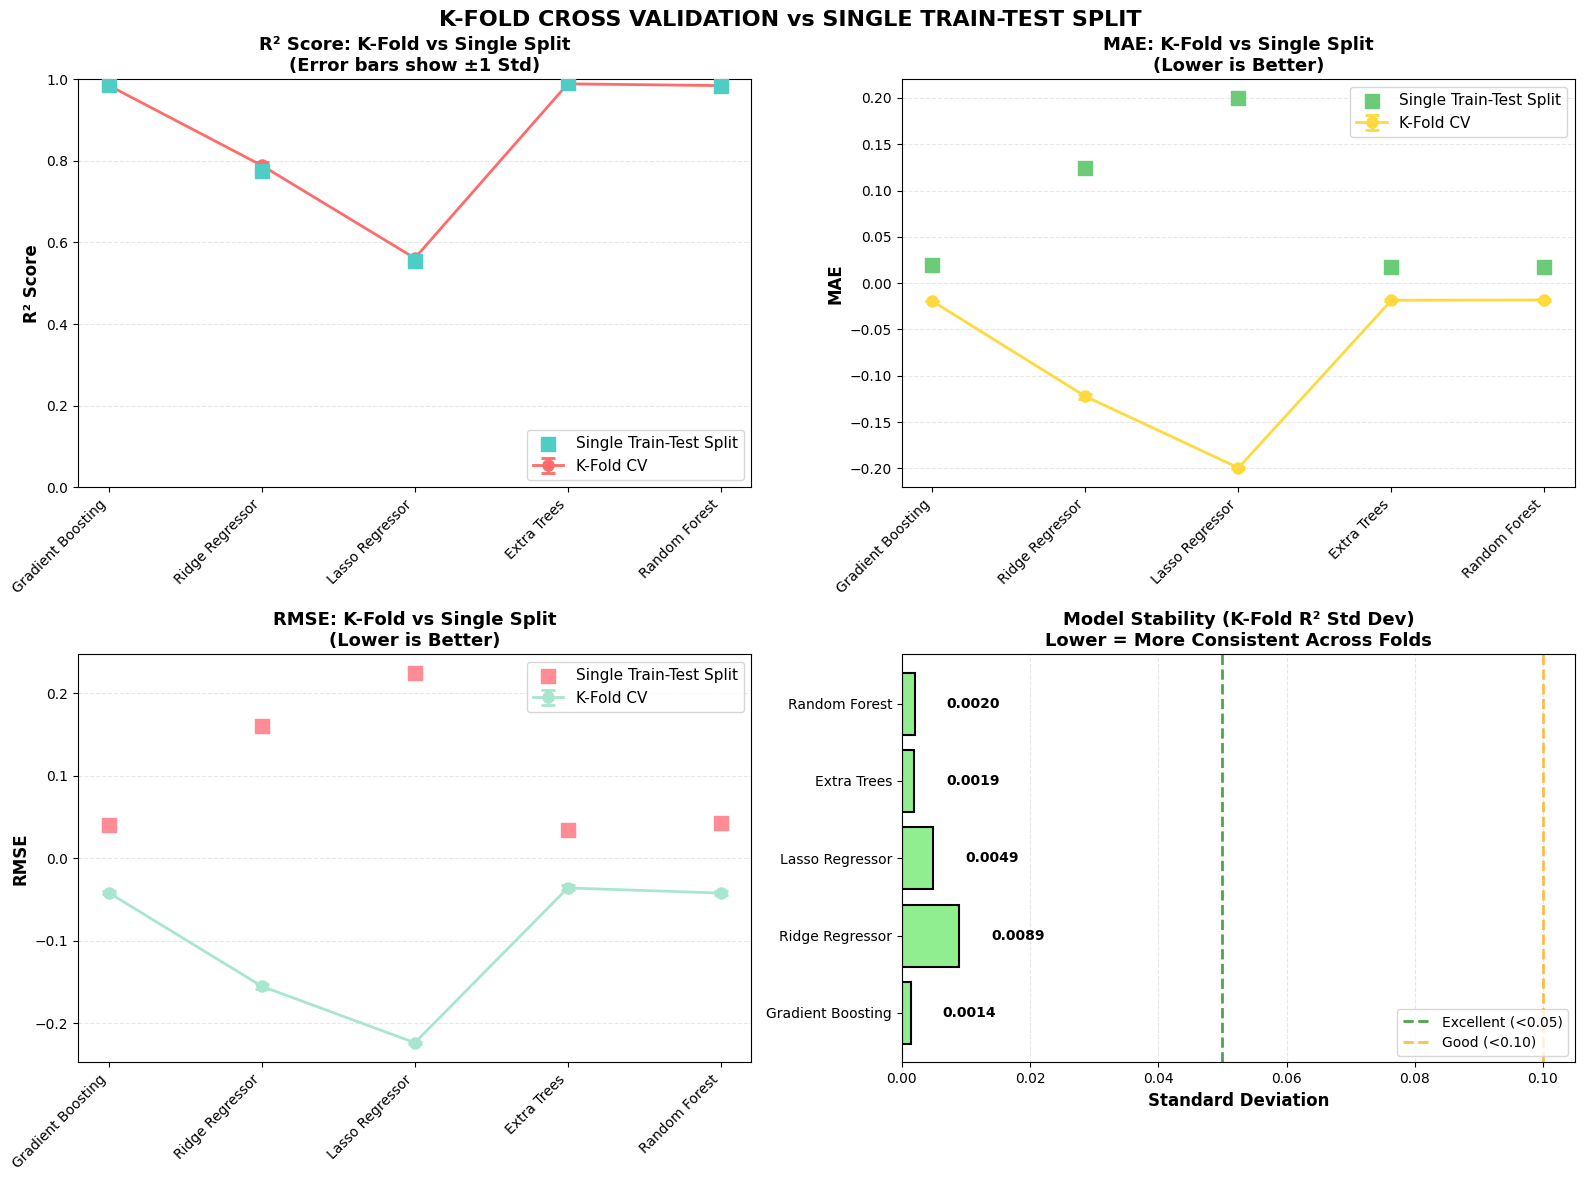


JUSTIFICATION: WHY K-FOLD CROSS VALIDATION IS IMPORTANT

1. PROBLEM WITH SINGLE TRAIN-TEST SPLIT:
   ├─ Only one evaluation → Lucky or unlucky split
   ├─ 20% test data might not be representative
   ├─ High variance in performance estimate
   └─ Example: Model A might look better just due to favorable split

2. ADVANTAGES OF K-FOLD CROSS VALIDATION (K=5):
   ├─ Every data point used for both training AND testing
   ├─ 5 different splits → more robust evaluation
   ├─ Mean performance = true model capability
   ├─ Std Dev = model stability/robustness
   └─ Better estimate with smaller variance

3. INTERPRETATION OF RESULTS:
   ├─ R² (Mean): Average model performance across 5 folds
   ├─ R² (Std): How consistent model is across different data
   │   └─ Low Std = Stable model (good!)
   │   └─ High Std = Model sensitive to data split (risky)
   ├─ Compare with Single Split:
   │   └─ If similar → single split is representative
   │   └─ If very different → K-Fold more trustworthy
   └─ 

In [23]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer

print("="*80)
print("K-FOLD CROSS VALIDATION (K=5) - ROBUST MODEL EVALUATION")
print("="*80)

# Setup K-Fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Create scoring functions
def mae_scorer(y_true, y_pred):
    return -mean_absolute_error(y_true, y_pred)  # negative karena higher is better

def rmse_scorer(y_true, y_pred):
    return -np.sqrt(mean_squared_error(y_true, y_pred))

# Dictionary to store CV results
cv_results = {}

# Model list
models_list = [
    ('Gradient Boosting', model),
    ('Ridge Regressor', model_ridge),
    ('Lasso Regressor', model_lasso),
    ('Extra Trees', model_extra_trees),
    ('Random Forest', model_rf)
]

print("\nPerforming 5-Fold Cross Validation on all models...")
print("(This will train each model 5 times on different data splits)\n")

for model_name, model_obj in models_list:
    print(f"Processing: {model_name}...")
    
    # R² Score (higher is better)
    r2_cv = cross_val_score(model_obj, X, y, cv=kfold, scoring='r2')
    
    # MAE (negative so we need to negate back)
    mae_cv = -cross_val_score(model_obj, X, y, cv=kfold, 
                               scoring=make_scorer(mean_absolute_error))
    
    # RMSE (negative so we need to negate back)
    rmse_cv = -cross_val_score(model_obj, X, y, cv=kfold, 
                                scoring=make_scorer(lambda y_t, y_p: np.sqrt(mean_squared_error(y_t, y_p))))
    
    cv_results[model_name] = {
        'R2_scores': r2_cv,
        'R2_mean': r2_cv.mean(),
        'R2_std': r2_cv.std(),
        'MAE_scores': mae_cv,
        'MAE_mean': mae_cv.mean(),
        'MAE_std': mae_cv.std(),
        'RMSE_scores': rmse_cv,
        'RMSE_mean': rmse_cv.mean(),
        'RMSE_std': rmse_cv.std()
    }

print("\n" + "="*80)
print("K-FOLD CROSS VALIDATION RESULTS (Mean ± Std across 5 folds)")
print("="*80)

# Create comprehensive results table
cv_comparison = pd.DataFrame({
    'Model': [],
    'R² (Mean)': [],
    'R² (Std)': [],
    'MAE (Mean)': [],
    'MAE (Std)': [],
    'RMSE (Mean)': [],
    'RMSE (Std)': []
})

for model_name in cv_results.keys():
    new_row = pd.DataFrame({
        'Model': [model_name],
        'R² (Mean)': [cv_results[model_name]['R2_mean']],
        'R² (Std)': [cv_results[model_name]['R2_std']],
        'MAE (Mean)': [cv_results[model_name]['MAE_mean']],
        'MAE (Std)': [cv_results[model_name]['MAE_std']],
        'RMSE (Mean)': [cv_results[model_name]['RMSE_mean']],
        'RMSE (Std)': [cv_results[model_name]['RMSE_std']]
    })
    cv_comparison = pd.concat([cv_comparison, new_row], ignore_index=True)

print("\n" + cv_comparison.to_string(index=False))

print("\n" + "="*80)
print("COMPARISON: K-FOLD CV vs SINGLE TRAIN-TEST SPLIT")
print("="*80)

# Create side-by-side comparison
comparison_df = pd.DataFrame({
    'Model': models_comparison['Model'],
    'Single Split R²': models_comparison['Test R²'],
    'K-Fold CV R² (Mean)': [cv_results[m]['R2_mean'] for m in models_comparison['Model']],
    'K-Fold CV R² (Std)': [cv_results[m]['R2_std'] for m in models_comparison['Model']],
})

comparison_df['Difference'] = comparison_df['K-Fold CV R² (Mean)'] - comparison_df['Single Split R²']

print("\nR² Score Comparison:")
print(comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('K-FOLD CROSS VALIDATION vs SINGLE TRAIN-TEST SPLIT', 
             fontsize=16, fontweight='bold')

# 1. R² Score Comparison with Error Bars
ax1 = axes[0, 0]
x_pos = range(len(cv_comparison))
ax1.errorbar(x_pos, cv_comparison['R² (Mean)'], yerr=cv_comparison['R² (Std)'],
             fmt='o-', linewidth=2, markersize=8, label='K-Fold CV', capsize=5, capthick=2, color='#FF6B6B')
ax1.scatter(x_pos, models_comparison['Test R²'], marker='s', s=100, 
            label='Single Train-Test Split', color='#4ECDC4', zorder=5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(cv_comparison['Model'], rotation=45, ha='right')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('R² Score: K-Fold vs Single Split\n(Error bars show ±1 Std)', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0, 1.0])

# 2. MAE Comparison with Error Bars
ax2 = axes[0, 1]
ax2.errorbar(x_pos, cv_comparison['MAE (Mean)'], yerr=cv_comparison['MAE (Std)'],
             fmt='o-', linewidth=2, markersize=8, label='K-Fold CV', capsize=5, capthick=2, color='#FFD93D')
ax2.scatter(x_pos, models_comparison['Test MAE'], marker='s', s=100, 
            label='Single Train-Test Split', color='#6BCB77', zorder=5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(cv_comparison['Model'], rotation=45, ha='right')
ax2.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax2.set_title('MAE: K-Fold vs Single Split\n(Lower is Better)', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# 3. RMSE Comparison with Error Bars
ax3 = axes[1, 0]
ax3.errorbar(x_pos, cv_comparison['RMSE (Mean)'], yerr=cv_comparison['RMSE (Std)'],
             fmt='o-', linewidth=2, markersize=8, label='K-Fold CV', capsize=5, capthick=2, color='#A8E6CF')
ax3.scatter(x_pos, models_comparison['Test RMSE'], marker='s', s=100, 
            label='Single Train-Test Split', color='#FF8B94', zorder=5)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(cv_comparison['Model'], rotation=45, ha='right')
ax3.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax3.set_title('RMSE: K-Fold vs Single Split\n(Lower is Better)', 
              fontsize=13, fontweight='bold')
ax3.legend(fontsize=11, loc='upper right')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# 4. Standard Deviation Analysis (Stability)
ax4 = axes[1, 1]
colors_stability = ['#90EE90' if std < 0.05 else '#FFD700' if std < 0.10 else '#FF6B6B'
                    for std in cv_comparison['R² (Std)']]
bars = ax4.barh(cv_comparison['Model'], cv_comparison['R² (Std)'], color=colors_stability, edgecolor='black', linewidth=1.5)
ax4.set_xlabel('Standard Deviation', fontsize=12, fontweight='bold')
ax4.set_title('Model Stability (K-Fold R² Std Dev)\nLower = More Consistent Across Folds', 
              fontsize=13, fontweight='bold')
ax4.grid(axis='x', alpha=0.3, linestyle='--')
ax4.axvline(x=0.05, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Excellent (<0.05)')
ax4.axvline(x=0.10, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Good (<0.10)')
ax4.legend(fontsize=10, loc='lower right')
for i, (model, std) in enumerate(zip(cv_comparison['Model'], cv_comparison['R² (Std)'])):
    ax4.text(std + 0.005, i, f'{std:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("JUSTIFICATION: WHY K-FOLD CROSS VALIDATION IS IMPORTANT")
print("="*80)

justification_text = """
1. PROBLEM WITH SINGLE TRAIN-TEST SPLIT:
   ├─ Only one evaluation → Lucky or unlucky split
   ├─ 20% test data might not be representative
   ├─ High variance in performance estimate
   └─ Example: Model A might look better just due to favorable split

2. ADVANTAGES OF K-FOLD CROSS VALIDATION (K=5):
   ├─ Every data point used for both training AND testing
   ├─ 5 different splits → more robust evaluation
   ├─ Mean performance = true model capability
   ├─ Std Dev = model stability/robustness
   └─ Better estimate with smaller variance

3. INTERPRETATION OF RESULTS:
   ├─ R² (Mean): Average model performance across 5 folds
   ├─ R² (Std): How consistent model is across different data
   │   └─ Low Std = Stable model (good!)
   │   └─ High Std = Model sensitive to data split (risky)
   ├─ Compare with Single Split:
   │   └─ If similar → single split is representative
   │   └─ If very different → K-Fold more trustworthy
   └─ Error bars show confidence range

4. WHEN TO USE K-FOLD:
   ├─ Dataset size: < 100k samples (recommended)
   ├─ Model selection: Choose between algorithms
   ├─ Hyperparameter tuning: GridSearchCV + K-Fold
   ├─ Production deployment: Ensure model robustness
   └─ Reporting performance: Use K-Fold results

5. LIMITATION:
   ├─ Computational cost: 5x training time vs single split
   ├─ For very large datasets (>1M): Use simple split
   └─ Trade-off: Accuracy vs Speed

6. BEST PRACTICE WORKFLOW:
   ├─ Step 1: Use simple train-test split → Quick baseline
   ├─ Step 2: Use K-Fold CV → Robust evaluation (THIS)
   ├─ Step 3: Use Stratified K-Fold → For imbalanced data
   ├─ Step 4: Nested CV + GridSearch → Final hyperparameter tuning
   └─ Step 5: Hold-out test set → Final deployment evaluation

7. STANDARD IN INDUSTRY:
   ├─ Academic papers: K-Fold CV adalah standard
   ├─ Kaggle competitions: K-Fold CV mandatory
   ├─ Production ML: K-Fold untuk model validation
   └─ Best practice: Report both mean AND std of KFold results
"""

print(justification_text)

print("\n" + "="*80)
print("FINAL INTERPRETATION")
print("="*80)

best_kfold_model = cv_comparison.loc[cv_comparison['R² (Mean)'].idxmax()]
print(f"""
Best Model (K-Fold CV): {best_kfold_model['Model']}
  R² Score: {best_kfold_model['R² (Mean)']:.6f} ± {best_kfold_model['R² (Std)']:.6f}
  MAE: {best_kfold_model['MAE (Mean)']:.6f} ± {best_kfold_model['MAE (Std)']:.6f}
  RMSE: {best_kfold_model['RMSE (Mean)']:.6f} ± {best_kfold_model['RMSE (Std)']:.6f}

Stability: {'Excellent' if best_kfold_model['R² (Std)'] < 0.05 else 'Good' if best_kfold_model['R² (Std)'] < 0.10 else 'Fair'}

Recommendation: 
  This model is {'HIGHLY' if best_kfold_model['R² (Std)'] < 0.05 else ''} recommended for production
  deployment because it shows consistent performance across different data splits.
""")
